# API cost estimation — gpt-5.5 over the compacted filings + news dataset

**Question:** what would it cost to push every compacted document (10-K / 10-Q / 8-K / news)
through gpt-5.5 with a simple "give me investment insight" prompt, for all 32 companies?

**Method**
1. Inventory every document on disk and count its tokens locally with `tiktoken` (free).
   Filings are counted exactly; the news PDFs are estimated from a seeded random sample
   of articles (95% CI reported).
2. Sample a few documents *per type* — filings from one company, news from the shared
   pool — and actually run them through the API, recording input / output /
   hidden-reasoning tokens from the `usage` object.
3. From the samples, get each type's **output-per-input-token ratio** and a blended
   **$ per 1M input tokens** rate.
4. Calibrate the tiktoken counts against API-reported input tokens, apply the per-type
   ratios to the full inventory, and scale: filings per-company x 32, news x `NEWS_SCALE`
   (news is market-wide, so it doesn't scale with company count).

Sampled API responses are cached in `results/samples.csv` — re-running the notebook does
**not** re-spend. New documents dropped into `data/filings/` or `data/news/` are picked
up on rerun, and only new samples get billed.


In [1]:
import hashlib, json, os, re, time
from pathlib import Path

import numpy as np
import pandas as pd
import tiktoken
from dotenv import load_dotenv
from IPython.display import display


def find_project_dir():
    for cand in [Path.cwd(), Path.cwd().parent, Path.cwd() / "api_cost", Path.cwd().parent / "api_cost"]:
        if (cand / ".env").exists() and (cand / "data" / "filings").is_dir():
            return cand.resolve()
    raise FileNotFoundError("could not locate the api_cost project dir (needs .env and data/filings)")


PROJECT_DIR = find_project_dir()
load_dotenv(PROJECT_DIR / ".env")
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY not found in api_cost/.env"

MODEL = os.getenv("OPENAI_MODEL", "gpt-5.5")
REASONING_EFFORT = "medium"  # API default; reasoning tokens are billed as output tokens

# USD per 1M tokens for gpt-5.5, verified 2026-07-07 against
# https://developers.openai.com/api/docs/pricing ($0.50/1M cached input also available;
# unused here since every document is sent once)
PRICE_IN, PRICE_OUT = 5.00, 30.00

FILINGS_DIR = PROJECT_DIR / "data" / "filings"
NEWS_DIR = PROJECT_DIR / "data" / "news"
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)
SAMPLES_CSV = RESULTS_DIR / "samples.csv"        # per-call token/cost metrics (doubles as the cache)
RESPONSES_JSONL = RESULTS_DIR / "responses.jsonl"  # full model responses, for eyeballing quality

SAMPLE_COMPANY = "Northbridge Systems"
VALIDATION_COMPANY = None   # e.g. "Summit Harvest Foods" — see section 8
N_PER_TYPE = 3              # documents sampled per doc type
TOTAL_COMPANIES = 32        # extrapolation target for filings
NEWS_TOKEN_SAMPLE = 400     # news PDFs token-counted (seeded random sample) to estimate the corpus
NEWS_SCALE = 1.0            # multiplier on news volume if more sources are still coming
SEED = 42
CONFIRM_SPEND = False       # flip to True to authorize the paid sampling in section 4
NEWS_TOKENS_CSV = RESULTS_DIR / "news_token_sample.csv"  # cache for the news token sample

PROMPT = "Given the document provided, please return any relevant investment insight you can."

print(f"project: {PROJECT_DIR}")
print(f"model:   {MODEL} (reasoning effort: {REASONING_EFFORT})")
print(f"pricing: ${PRICE_IN:.2f}/1M input, ${PRICE_OUT:.2f}/1M output")
print(f"sample:  {SAMPLE_COMPANY!r}, up to {N_PER_TYPE} docs per type")


project: /home/kavin-ravi/CodingStuff/quant_finance_project/api_cost
model:   gpt-5.5 (reasoning effort: medium)
pricing: $5.00/1M input, $30.00/1M output
sample:  'Northbridge Systems', up to 3 docs per type


## 1. Data discovery

Filings live in `data/filings/<company>/<date>_<type>[_n].txt` (date may be `unknown`,
`_n` disambiguates multiple same-day filings); the type is parsed straight from the
filename and anything unrecognized is flagged as `other` rather than silently dropped.
News lives in `data/news/<source>/` as PDFs (plus any `.txt`/`.md`); the `company`
column holds the *source* name for news, since articles are market-wide rather than
per-company.


In [2]:
FILING_RE = re.compile(r"^(\d{4}-\d{2}-\d{2}|unknown)_(10-K|10-Q|8-K)(?:_\d+)?\.txt$")
NEWS_DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")
NEWS_SUFFIXES = {".pdf", ".txt", ".md"}

rows = []
for f in sorted(FILINGS_DIR.rglob("*.txt")):
    m = FILING_RE.match(f.name)
    rows.append({"company": f.parent.name, "doc_type": m.group(2) if m else "other",
                 "date": m.group(1) if m else None, "path": str(f), "bytes": f.stat().st_size})

news_files = [f for f in sorted(NEWS_DIR.rglob("*")) if f.is_file()]
for f in news_files:
    if f.suffix.lower() in NEWS_SUFFIXES:
        d = NEWS_DATE_RE.search(f.name)
        rows.append({"company": f.parent.name if f.parent != NEWS_DIR else "(unassigned)",
                     "doc_type": "news", "date": d.group(1) if d else None,
                     "path": str(f), "bytes": f.stat().st_size})

docs = pd.DataFrame(rows)

skipped = [f.name for f in news_files if f.suffix.lower() not in NEWS_SUFFIXES]
if skipped:
    print(f"NOTE: {len(skipped)} unsupported news files skipped {skipped[:5]}"
          " — extend NEWS_SUFFIXES / add a parser for that format")
if not (docs["doc_type"] == "news").any():
    print("NOTE: no news articles yet (zip still downloading?) — rerun from here once data/news is populated\n")

print(f"{len(docs)} documents across {docs['company'].nunique()} companies")
(docs.groupby("doc_type")
     .agg(n_docs=("path", "count"),
          total_MB=("bytes", lambda b: b.sum() / 1e6),
          mean_KB=("bytes", lambda b: b.mean() / 1e3))
     .round(2))


9121 documents across 9 companies


,n_docs,total_MB,mean_KB
doc_type,,,
10-K,56,2.20,39.35
10-Q,168,1.20,7.13
8-K,722,1.06,1.47
news,8175,855.83,104.69


## 2. Token inventory (local, free)

Filings are plain text and get *exact* `tiktoken` counts. News PDFs are too numerous to
extract exhaustively (thousands), so a seeded random sample of `NEWS_TOKEN_SAMPLE`
articles is extracted with `pypdf` and token-counted; the news corpus total is
`mean x article_count`, reported with a 95% CI, and the sample is cached to
`results/news_token_sample.csv` so reruns are instant. gpt-5.x uses the `o200k_base`
family; the small mismatch vs API-reported counts is corrected in section 6.


In [3]:
import pypdf

try:
    ENC = tiktoken.encoding_for_model(MODEL)
except KeyError:
    ENC = tiktoken.get_encoding("o200k_base")
PROMPT_TOKENS = len(ENC.encode(PROMPT))


def read_doc_text(path):
    p = Path(path)
    if p.suffix.lower() == ".pdf":
        try:
            return "\n".join(page.extract_text() or "" for page in pypdf.PdfReader(p).pages)
        except Exception:
            return ""  # broken PDF -> 0 tokens, reported below
    return p.read_text(encoding="utf-8", errors="ignore")


def count_tokens(path):
    return len(ENC.encode(read_doc_text(path)))


# filings: small, plain text -> exact counts
docs["doc_tokens"] = np.nan
is_news = docs["doc_type"] == "news"
docs.loc[~is_news, "doc_tokens"] = docs.loc[~is_news, "path"].map(count_tokens)
filings_total = int(docs.loc[~is_news, "doc_tokens"].sum())

# news: seeded random sample of PDFs, cached across reruns
NEWS_N = int(is_news.sum())
NEWS_TOTAL_TOKENS = 0.0
if NEWS_N:
    rng = np.random.default_rng(SEED)
    wanted = set(rng.choice(docs.loc[is_news, "path"].to_numpy(),
                            size=min(NEWS_TOKEN_SAMPLE, NEWS_N), replace=False))
    cached = (pd.read_csv(NEWS_TOKENS_CSV).set_index("path")["tokens"]
              if NEWS_TOKENS_CSV.exists() else pd.Series(dtype=float, name="tokens"))
    todo = sorted(wanted - set(cached.index))
    if todo:
        print(f"extracting + token-counting {len(todo)} news PDFs (one-time, cached)...")
        counted = {}
        for i, p in enumerate(todo, 1):
            counted[p] = count_tokens(p)
            if i % 100 == 0:
                print(f"  {i}/{len(todo)}")
        new = pd.Series(counted, name="tokens", dtype=float)
        cached = new if cached.empty else pd.concat([cached, new])
        cached.rename_axis("path").reset_index().to_csv(NEWS_TOKENS_CSV, index=False)
    sample_counts = cached[cached.index.isin(wanted)]
    docs.loc[is_news, "doc_tokens"] = docs.loc[is_news, "path"].map(sample_counts)
    empty = int((sample_counts == 0).sum())
    if empty:
        print(f"WARNING: {empty}/{len(sample_counts)} sampled PDFs had no extractable text")
    mean_tok = sample_counts.mean()
    ci = 1.96 * sample_counts.std() / np.sqrt(len(sample_counts))
    NEWS_TOTAL_TOKENS = mean_tok * NEWS_N
    print(f"news: {NEWS_N:,} PDFs; sampled {len(sample_counts)} -> {mean_tok:,.0f} ± {ci:,.0f} tokens/article (95% CI)")
    print(f"news corpus estimate: {NEWS_TOTAL_TOKENS / 1e6:.2f}M ± {ci * NEWS_N / 1e6:.2f}M tokens")

print(f"\nencoding: {ENC.name} | task prompt adds {PROMPT_TOKENS} tokens per call")
print(f"filings corpus (exact): {filings_total:,} tokens | news corpus (est.): {NEWS_TOTAL_TOKENS / 1e6:.2f}M tokens")

display(docs[~is_news].groupby("doc_type")["doc_tokens"]
            .agg(n_docs="count", total_tokens="sum", mean_tokens="mean", std_tokens="std")
            .round(0))
docs[~is_news].groupby("company")["doc_tokens"].sum().sort_values(ascending=False).to_frame("filing_tokens")


news: 8,175 PDFs; sampled 400 -> 1,013 ± 28 tokens/article (95% CI)
news corpus estimate: 8.28M ± 0.23M tokens

encoding: o200k_base | task prompt adds 14 tokens per call
filings corpus (exact): 955,706 tokens | news corpus (est.): 8.28M tokens


,n_docs,total_tokens,mean_tokens,std_tokens
doc_type,,,,
10-K,56,412583.0,7368.0,1909.0
10-Q,168,284535.0,1694.0,154.0
8-K,722,258588.0,358.0,136.0


,filing_tokens
company,
Sabino Card Services,140134.0
Atlantic Trust Financial,127160.0
BlueRidge Logistics,126401.0
Cresthaven Health,126181.0
Halstead Retail Group,121870.0
Silverline Creative Systems,119760.0
Northbridge Systems,110060.0
Summit Harvest Foods,84140.0


## 3. Sample selection

Up to `N_PER_TYPE` documents per type from the sample company, spread evenly across each
type's size distribution (8-Ks in particular are bimodal — some are one-liners, some carry
exhibits) so the mean isn't skewed by which sizes happened to be drawn. News is sampled
from the token-counted subset regardless of company, since articles aren't per-company.


In [4]:
def pick_samples(company, n_per_type=N_PER_TYPE):
    pool = docs[(docs["doc_tokens"] > 0)   # excludes un-counted news and empty extractions
                & ((docs["company"] == company) | (docs["doc_type"] == "news"))]
    if pool.empty:
        raise ValueError(f"no documents found for company {company!r}")
    picks = []
    for _, g in pool.groupby("doc_type"):
        g = g.sort_values("doc_tokens").reset_index(drop=True)
        idx = np.unique(np.linspace(0, len(g) - 1, min(n_per_type, len(g))).round().astype(int))
        picks.append(g.iloc[idx])
    return pd.concat(picks, ignore_index=True)


samples = pick_samples(SAMPLE_COMPANY)
print(f"{len(samples)} sample docs from {SAMPLE_COMPANY!r} + news pool ({samples['doc_tokens'].sum():,.0f} document tokens)")
samples[["company", "doc_type", "date", "doc_tokens", "path"]]


12 sample docs from 'Northbridge Systems' + news pool (29,830 document tokens)


,company,doc_type,date,doc_tokens,path
0,Northbridge Systems,10-K,2019-05-31,6025.0,/home/kavin-ravi/CodingStuff/quant_finance_pro...
1,Northbridge Systems,10-K,2065-08-03,6025.0,/home/kavin-ravi/CodingStuff/quant_finance_pro...
2,Northbridge Systems,10-K,2061-03-25,8265.0,/home/kavin-ravi/CodingStuff/quant_finance_pro...
3,Northbridge Systems,10-Q,2019-02-28,1747.0,/home/kavin-ravi/CodingStuff/quant_finance_pro...
4,Northbridge Systems,10-Q,2024-05-31,1747.0,/home/kavin-ravi/CodingStuff/quant_finance_pro...
5,Northbridge Systems,10-Q,2065-09-26,1747.0,/home/kavin-ravi/CodingStuff/quant_finance_pro...
6,Northbridge Systems,8-K,unknown,258.0,/home/kavin-ravi/CodingStuff/quant_finance_pro...
7,Northbridge Systems,8-K,2021-12-20,264.0,/home/kavin-ravi/CodingStuff/quant_finance_pro...
8,Northbridge Systems,8-K,2025-12-10,554.0,/home/kavin-ravi/CodingStuff/quant_finance_pro...
9,The_Camden_Chronicle,news,2023-05-26,313.0,/home/kavin-ravi/CodingStuff/quant_finance_pro...


## 4. Paid sampling run

The only cell that costs money. Guard rails:

- **`CONFIRM_SPEND` must be `True`** (config cell) or this raises before any API call.
- Every call is cached to `results/samples.csv` keyed on *(file, model, effort, prompt)* —
  reruns and `Restart & Run All` skip anything already measured.
- Results are written incrementally, so an interruption loses at most one call.

`usage.output_tokens` **includes the hidden reasoning tokens**; they're broken out
separately below because they're invisible in the response text but very visible on the bill.
Full response texts land in `results/responses.jsonl` if you want to judge output quality.


In [5]:
from openai import OpenAI

PROMPT_SHA = hashlib.sha256(PROMPT.encode()).hexdigest()[:12]


def cache_key(path):
    return f"{Path(path).relative_to(PROJECT_DIR)}|{MODEL}|{REASONING_EFFORT}|{PROMPT_SHA}"


def load_cache():
    return pd.read_csv(SAMPLES_CSV) if SAMPLES_CSV.exists() else pd.DataFrame()


def call_model(client, path):
    text = read_doc_text(path)  # handles both plain text and PDF
    for attempt in range(3):
        try:
            resp = client.responses.create(model=MODEL,
                                           reasoning={"effort": REASONING_EFFORT},
                                           input=f"{PROMPT}\n\n---\n\n{text}")
            break
        except Exception as e:
            if "insufficient_quota" in str(e) or attempt == 2:
                raise  # no-credit errors never resolve by retrying
            wait = 15 * (attempt + 1)
            print(f"    retry in {wait}s after {type(e).__name__}: {e}")
            time.sleep(wait)
    u = resp.usage
    reasoning = getattr(u.output_tokens_details, "reasoning_tokens", 0) or 0
    return resp, {"key": cache_key(path), "model": MODEL, "effort": REASONING_EFFORT,
                  "api_input_tokens": u.input_tokens,
                  "api_output_tokens": u.output_tokens,   # includes reasoning
                  "reasoning_tokens": reasoning,
                  "visible_output_tokens": u.output_tokens - reasoning,
                  "cost_usd": u.input_tokens / 1e6 * PRICE_IN + u.output_tokens / 1e6 * PRICE_OUT}


def run_samples(sample_df):
    cache = load_cache()
    done = set(cache["key"]) if not cache.empty else set()
    todo = sample_df[~sample_df["path"].map(cache_key).isin(done)]

    if todo.empty:
        print(f"all {len(sample_df)} samples already cached in {SAMPLES_CSV.name} — no API spend")
    else:
        est_in = todo["doc_tokens"].sum() + PROMPT_TOKENS * len(todo)
        assumed_out = 2500  # rough per-doc output prior (incl. reasoning), for the guard only
        est_cost = est_in / 1e6 * PRICE_IN + assumed_out * len(todo) / 1e6 * PRICE_OUT
        print(f"{len(todo)} uncached samples -> ~{est_in:,.0f} input tokens, rough cost ~${est_cost:.2f}")
        if not CONFIRM_SPEND:
            raise RuntimeError("CONFIRM_SPEND is False — flip it in the config cell to authorize this spend")
        client = OpenAI(timeout=600)
        for i, row in enumerate(todo.itertuples(), 1):
            print(f"  [{i}/{len(todo)}] {row.doc_type:5s} {Path(row.path).name} ({row.doc_tokens:,} tok in)", end=" ")
            resp, rec = call_model(client, row.path)
            rec.update(path=row.path, company=row.company, doc_type=row.doc_type, doc_tokens=row.doc_tokens)
            with open(RESPONSES_JSONL, "a") as f:
                f.write(json.dumps({"key": rec["key"], "response": resp.output_text}) + "\n")
            cache = pd.concat([cache, pd.DataFrame([rec])], ignore_index=True)
            cache.to_csv(SAMPLES_CSV, index=False)  # incremental save: a crash loses at most one call
            print(f"-> {rec['api_output_tokens']:,} out ({rec['reasoning_tokens']:,} reasoning), ${rec['cost_usd']:.4f}")

    cache = load_cache()
    return cache[cache["key"].isin(set(sample_df["path"].map(cache_key)))].copy()


results = run_samples(samples)
print(f"\nspend for this sample set: ${results['cost_usd'].sum():.2f}")
results[["doc_type", "doc_tokens", "api_input_tokens", "api_output_tokens",
         "reasoning_tokens", "cost_usd"]].sort_values("doc_type")


12 uncached samples -> ~29,998 input tokens, rough cost ~$1.05
  [1/12] 10-K  2019-05-31_10-K.txt (6,025.0 tok in) 

-> 1,436 out (407 reasoning), $0.0733
  [2/12] 10-K  2065-08-03_10-K.txt (6,025.0 tok in) 

-> 1,659 out (317 reasoning), $0.0800
  [3/12] 10-K  2061-03-25_10-K_4.txt (8,265.0 tok in) 

-> 1,940 out (458 reasoning), $0.0996
  [4/12] 10-Q  2019-02-28_10-Q.txt (1,747.0 tok in) 

-> 1,517 out (418 reasoning), $0.0543
  [5/12] 10-Q  2024-05-31_10-Q.txt (1,747.0 tok in) 

...

-> 392 out (131 reasoning), $0.0146
  [10/12] news  camden_2023-05-26_tell-us-has-your-uk-energy-supplier-back-billed-you-by-more--097cc2.pdf (313.0 tok in) 

-> 498 out (166 reasoning), $0.0166
  [11/12] news  camden_2020-12-02_covid-crisis-offers-a-chance-to-act-on-climate-report-says-15480d.pdf (1,021.0 tok in) 

-> 815 out (149 reasoning), $0.0297
  [12/12] news  camden_2019-08-23_hasbro-buys-peppa-pig-owner-entertainment-one-in-3-3bn-deal-442297.pdf (1,864.0 tok in) 

-> 1,111 out (516 reasoning), $0.0428

spend for this sample set: $0.54


,doc_type,doc_tokens,api_input_tokens,api_output_tokens,reasoning_tokens,cost_usd
0,10-K,6025.0,6046,1436,407,0.073310
1,10-K,6025.0,6046,1659,317,0.080000
2,10-K,8265.0,8286,1940,458,0.099630
3,10-Q,1747.0,1768,1517,418,0.054350
4,10-Q,1747.0,1768,1799,516,0.062810
5,10-Q,1747.0,1768,1231,189,0.045770
6,8-K,258.0,279,348,84,0.011835
7,8-K,264.0,285,327,91,0.011235
8,8-K,554.0,575,392,131,0.014635
9,news,313.0,334,498,166,0.016610


## 5. Per-type token & cost statistics

`out_per_in` is the workhorse number: total output tokens / total input tokens per type.
`blended_usd_per_1M_input` = `PRICE_IN + out_per_in * PRICE_OUT` — the *all-in* cost of
pushing 1M input tokens of that document type through the model.


In [6]:
def per_type_stats(res):
    g = res.groupby("doc_type")
    out = pd.DataFrame({
        "n": g.size(),
        "mean_input_tok": g["api_input_tokens"].mean(),
        "mean_output_tok": g["api_output_tokens"].mean(),
        "mean_reasoning_tok": g["reasoning_tokens"].mean(),
        "output_std": g["api_output_tokens"].std(),
        "out_per_in": g["api_output_tokens"].sum() / g["api_input_tokens"].sum(),
        "mean_cost_usd": g["cost_usd"].mean(),
    })
    out["blended_usd_per_1M_input"] = PRICE_IN + out["out_per_in"] * PRICE_OUT
    return out


stats = per_type_stats(results)
share = results["reasoning_tokens"].sum() / results["api_output_tokens"].sum()
print(f"hidden reasoning tokens are {share:.0%} of all billed output tokens")
stats.round(3)


hidden reasoning tokens are 26% of all billed output tokens


,n,mean_input_tok,mean_output_tok,mean_reasoning_tok,output_std,out_per_in,mean_cost_usd,blended_usd_per_1M_input
doc_type,,,,,,,,
10-K,3,6792.667,1678.333,394.000,252.556,0.247,0.084,12.412
10-Q,3,1768.000,1515.667,374.333,284.002,0.857,0.054,30.718
8-K,3,379.667,355.667,102.000,33.171,0.937,0.013,33.104
news,3,1087.000,808.000,277.000,306.560,0.743,0.030,27.300


## 6. Calibration — tiktoken vs API-reported input tokens

The API bills a few more input tokens than raw text tokenization (message framing).
Measured on the samples and applied to the full inventory so the extrapolation matches
what the meter would actually read.


In [7]:
CALIB = (results["api_input_tokens"] / (results["doc_tokens"] + PROMPT_TOKENS)).mean()
print(f"calibration factor: x{CALIB:.4f} "
      f"(API reports {(CALIB - 1) * 100:+.2f}% vs tiktoken doc+prompt count)")


calibration factor: x1.0092 (API reports +0.92% vs tiktoken doc+prompt count)


## 7. Full-dataset cost & extrapolation

Per-type input totals (filings exact, news `mean x count`) with per-type output ratios
from section 5. **Filings** scale by `TOTAL_COMPANIES / local companies`; **news** is
market-wide so it gets no per-company scaling — bump `NEWS_SCALE` instead if more
sources are coming. Types with no measured samples yet are excluded and flagged.


In [8]:
rows = []
for doc_type, g in docs.groupby("doc_type"):
    if doc_type == "news":
        rows.append({"doc_type": doc_type, "n_docs": NEWS_N * NEWS_SCALE,
                     "corpus_tokens": NEWS_TOTAL_TOKENS * NEWS_SCALE})
    else:
        rows.append({"doc_type": doc_type, "n_docs": len(g),
                     "corpus_tokens": g["doc_tokens"].sum()})
dataset = pd.DataFrame(rows).set_index("doc_type")

n_local = docs.loc[docs["doc_type"] != "news", "company"].nunique()
company_scale = TOTAL_COMPANIES / n_local
dataset["est_input_tok"] = ((dataset["corpus_tokens"] + dataset["n_docs"] * PROMPT_TOKENS) * CALIB).round().astype("int64")
dataset = dataset.join(stats["out_per_in"])
dataset["est_output_tok"] = (dataset["est_input_tok"] * dataset["out_per_in"]).round()
dataset["est_cost_usd"] = (dataset["est_input_tok"] / 1e6 * PRICE_IN
                           + dataset["est_output_tok"] / 1e6 * PRICE_OUT)
dataset["scale"] = np.where(dataset.index == "news", 1.0, company_scale)
dataset["est_input_scaled"] = dataset["est_input_tok"] * dataset["scale"]
dataset["est_cost_scaled"] = dataset["est_cost_usd"] * dataset["scale"]

unmeasured = dataset.index[dataset["out_per_in"].isna()].tolist()
if unmeasured:
    print(f"WARNING: no samples measured yet for {unmeasured} — excluded from totals below")
measured = dataset.dropna(subset=["out_per_in"])

fil = measured[measured.index != "news"]
news_row = measured[measured.index == "news"]
total_cost = measured["est_cost_scaled"].sum()
total_in = measured["est_input_scaled"].sum()

print(f"filings, {n_local} local companies: {fil['est_input_tok'].sum() / 1e6:.2f}M input tokens"
      f" -> ${fil['est_cost_usd'].sum():,.2f} (${fil['est_cost_usd'].sum() / n_local:,.2f}/company)")
print(f"filings, scaled x{company_scale:.1f} to {TOTAL_COMPANIES} companies -> ${fil['est_cost_scaled'].sum():,.2f}")
if not news_row.empty:
    print(f"news, {NEWS_N:,} articles x NEWS_SCALE={NEWS_SCALE:g}: "
          f"{news_row['est_input_tok'].sum() / 1e6:.2f}M input tokens -> ${news_row['est_cost_scaled'].sum():,.2f}")
print()
print(f"=== full-dataset estimate: ${total_cost:,.2f} (~{total_in / 1e6:.1f}M input tokens) ===")
print(f"=== all-in blended rate: ${total_cost / total_in * 1e6:,.2f} per 1M input tokens ===")
print(f"    (raw prices are ${PRICE_IN}/1M in + ${PRICE_OUT}/1M out; the blended rate is higher"
      " because every input token drags output + reasoning tokens with it)")
dataset.round(3)


filings, 8 local companies: 0.98M input tokens -> $23.05 ($2.88/company)
filings, scaled x4.0 to 32 companies -> $92.19
news, 8,175 articles x NEWS_SCALE=1: 8.47M input tokens -> $231.35

=== full-dataset estimate: $323.54 (~12.4M input tokens) ===
=== all-in blended rate: $26.12 per 1M input tokens ===
    (raw prices are $5.0/1M in + $30.0/1M out; the blended rate is higher because every input token drags output + reasoning tokens with it)


,n_docs,corpus_tokens,est_input_tok,out_per_in,est_output_tok,est_cost_usd,scale,est_input_scaled,est_cost_scaled
doc_type,,,,,,,,,
10-K,56.0,412583.000,417164,0.247,103073.0,5.178,4.0,1668656.0,20.712
10-Q,168.0,284535.000,289522,0.857,248201.0,8.894,4.0,1158088.0,35.575
8-K,722.0,258588.000,271164,0.937,254023.0,8.977,4.0,1084656.0,35.906
news,8175.0,8282848.688,8474432,0.743,6299302.0,231.351,1.0,8474432.0,231.351


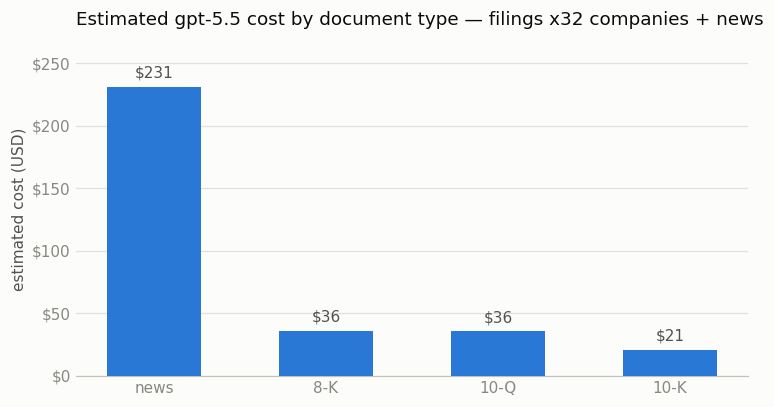

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

SERIES, SURFACE = "#2a78d6", "#fcfcfb"
INK, INK2, MUTED, GRID, BASELINE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"

per_type_scaled = measured["est_cost_scaled"].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3.8), dpi=110)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
bars = ax.bar(per_type_scaled.index, per_type_scaled.values, width=0.55, color=SERIES, zorder=3)
ax.bar_label(bars, fmt="${:,.0f}", padding=4, color=INK2, fontsize=10)
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.0f}"))
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(colors=MUTED, length=0)
ax.set_ylabel("estimated cost (USD)", color=INK2, fontsize=10)
ax.set_title(f"Estimated gpt-5.5 cost by document type — filings x{TOTAL_COMPANIES} companies + news",
             color=INK, fontsize=12, loc="left", pad=12)
ax.margins(y=0.15)
plt.tight_layout()
plt.show()


## 8. Validation company (optional)

Single-company sampling is the cheap version of this study. To check it isn't fooling us,
set `VALIDATION_COMPANY` in the config cell and rerun — the same pipeline runs on the
second company (cached + spend-guarded like everything else) and compares the per-type
ratios. If `rel_diff` stays within roughly ±20%, the extrapolation is on solid ground.


In [10]:
if VALIDATION_COMPANY:
    val_results = run_samples(pick_samples(VALIDATION_COMPANY))
    comparison = pd.concat({SAMPLE_COMPANY: per_type_stats(results)["out_per_in"],
                            VALIDATION_COMPANY: per_type_stats(val_results)["out_per_in"]}, axis=1)
    comparison["rel_diff"] = comparison[VALIDATION_COMPANY] / comparison[SAMPLE_COMPANY] - 1
    display(comparison.round(3))
else:
    print("set VALIDATION_COMPANY in the config cell (e.g. 'Summit Harvest Foods') and rerun"
          " to sanity-check the per-type ratios on a second company")


set VALIDATION_COMPANY in the config cell (e.g. 'Summit Harvest Foods') and rerun to sanity-check the per-type ratios on a second company
